In [ ]:
# Parameters (papermill overrides these at execution time)
DATASET_CSV_PATH = "backend/data/US_Group_ML_Dataset_2025_2026_refined_2.csv"  # relocated from project root
INPUT_JSON_PATH = "input.json"
OUTPUT_JSON_PATH = "output.json"


# Uploading File

In [216]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass  # not running in Colab - DATASET_CSV_PATH is read directly from disk instead


Saving US_Group_ML_Dataset_2025_2026_refined_2.csv to US_Group_ML_Dataset_2025_2026_refined_2.csv


# Imports

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Printing head

In [218]:
df = pd.read_csv(DATASET_CSV_PATH)
df.head()

,Order_ID,Order_Date,Dispatch_Date,Fiscal_Year,Fiscal_Quarter,Year,Month,Sub_Company,Division,Unit,Unit_Employee_Count,Unit_Monthly_Utilization_Pct,Customer_Name,Customer_Country,Customer_Segment,Order_Priority,Product_Category,UOM,Order_Quantity,Unit_Price_USD,Gross_Order_Value_USD,Discount_Pct,Discount_Amount_USD,Net_Order_Value_USD,Dispatch_Quantity,Dispatch_Value_USD,Exchange_Rate_PKR_per_USD,Dispatch_Value_PKR,Raw_Material_Cost_USD,Labor_Cost_USD,Overhead_Cost_USD,Energy_Cost_USD,COGS_USD,Freight_Cost_USD,Insurance_Cost_USD,Duty_Tax_USD,Total_Cost_USD,Gross_Profit_USD,Net_Profit_USD,Gross_Margin_Pct,Net_Margin_Pct,Payment_Terms,Advance_Payment_Pct,Credit_Days,Payment_Delay_Days,Defect_Rate_Pct,Return_Quantity,Shipping_Mode,Order_Status,Is_Profitable,Is_Delayed_Payment,Is_High_Value_Order
0,USG-2025-000013,2025-01-01,2025-02-10,FY2025,Q3,2025,1,US Denim,NaN,Unit 6,900,65.30,Davis-Joseph,Bangladesh,Regular,Medium,Denim Fabric,Meters,20690,3.90,80691.00,1.34,1081.26,79609.74,0,0.0,277.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TT 30 Days,1.6,30,0,1.80,0,Sea,Pending,0,0,0
1,USG-2025-000017,2025-01-01,2025-01-31,FY2025,Q3,2025,1,US Denim,NaN,Unit 6,900,65.30,Hale and Sons,Bangladesh,Key Account,Medium,Denim Fabric,Meters,55603,5.08,282463.24,2.74,7739.49,274723.75,0,0.0,277.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LC 90 Days,0.0,90,0,1.82,0,Sea,Cancelled,0,0,1
2,USG-2025-000026,2025-01-01,2025-02-03,FY2025,Q3,2025,1,US Denim,NaN,Unit 7,950,67.32,Duffy Group,Germany,Regular,Medium,Denim Fabric,Meters,35378,5.78,204484.84,0.13,265.83,204219.01,0,0.0,277.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LC 90 Days,0.0,90,0,1.42,0,Sea,Pending,0,0,1
3,USG-2025-000160,2025-01-01,2025-01-28,FY2025,Q3,2025,1,USAT,UK,Unit 3,1600,70.69,"McCarthy, Rose and Robinson",UK,New Customer,Medium,Twill Garments,Pieces,11000,7.86,86460.00,0.40,345.84,86114.16,0,0.0,277.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LC 90 Days,0.0,90,0,2.69,0,Sea,Pending,0,0,0
4,USG-2025-000127,2025-01-01,2025-02-16,FY2025,Q3,2025,1,USAT,USA,Unit 5,1100,74.02,Smith-Gamble,USA,Key Account,Low,Denim Garments,Pieces,3696,25.64,94765.44,3.09,2928.25,91837.19,0,0.0,277.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LC 60 Days,0.0,60,0,1.20,0,Sea,Pending,0,0,0


In [219]:
df.shape

(4845, 52)

# EDA

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Order_ID                      4845 non-null   object 
 1   Order_Date                    4845 non-null   object 
 2   Dispatch_Date                 4845 non-null   object 
 3   Fiscal_Year                   4845 non-null   object 
 4   Fiscal_Quarter                4845 non-null   object 
 5   Year                          4845 non-null   int64  
 6   Month                         4845 non-null   int64  
 7   Sub_Company                   4845 non-null   object 
 8   Division                      2440 non-null   object 
 9   Unit                          4845 non-null   object 
 10  Unit_Employee_Count           4845 non-null   int64  
 11  Unit_Monthly_Utilization_Pct  4845 non-null   float64
 12  Customer_Name                 4845 non-null   object 
 13  Cus

# Missing count

In [221]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Dispatch_Date,0
Fiscal_Year,0
Fiscal_Quarter,0
Year,0
Month,0
Sub_Company,0
Division,2405
Unit,0


In [222]:
df['Is_Profitable'].value_counts()


,count
Is_Profitable,
0,2474
1,2371


In [223]:
df['Is_Delayed_Payment'].value_counts()


,count
Is_Delayed_Payment,
0,4021
1,824


In [224]:
df['Order_Status'].value_counts()

,count
Order_Status,
Dispatched,2804
Delayed,717
Pending,706
Cancelled,618


# Order Distribution Plot

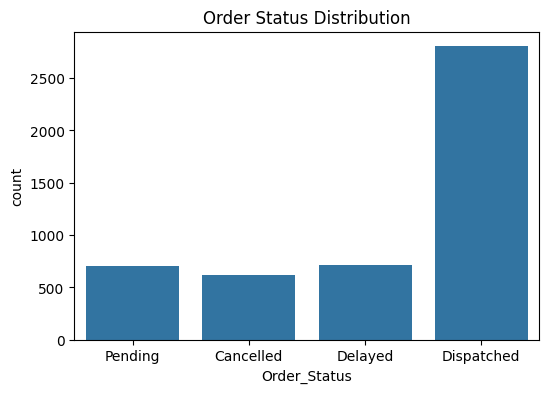

In [225]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Order_Status')
plt.title('Order Status Distribution')
plt.show()

# Sub-Company Plot

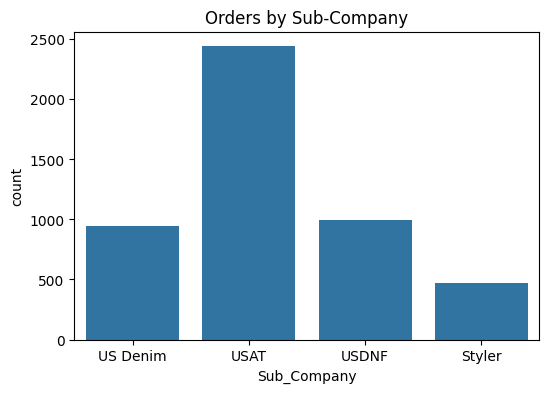

In [226]:
plt.figure(figsize=(6,4))
sns.countplot(data = df , x = 'Sub_Company')
plt.title('Orders by Sub-Company')
plt.show()

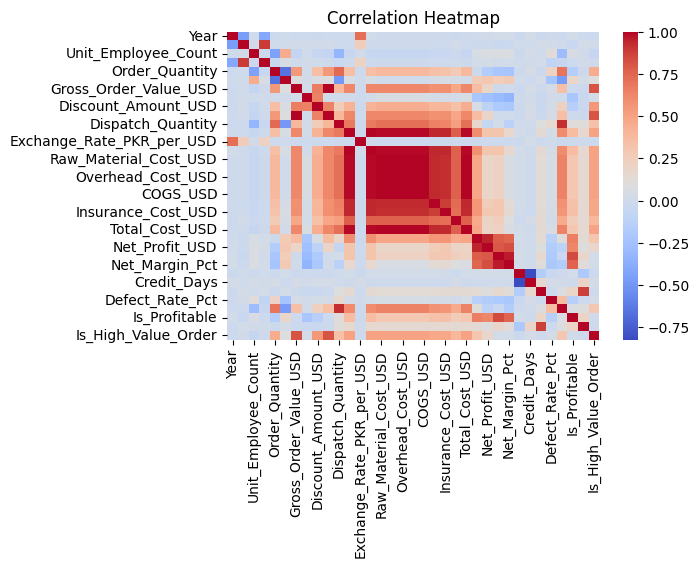

In [227]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only = True), annot = False , cmap ='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

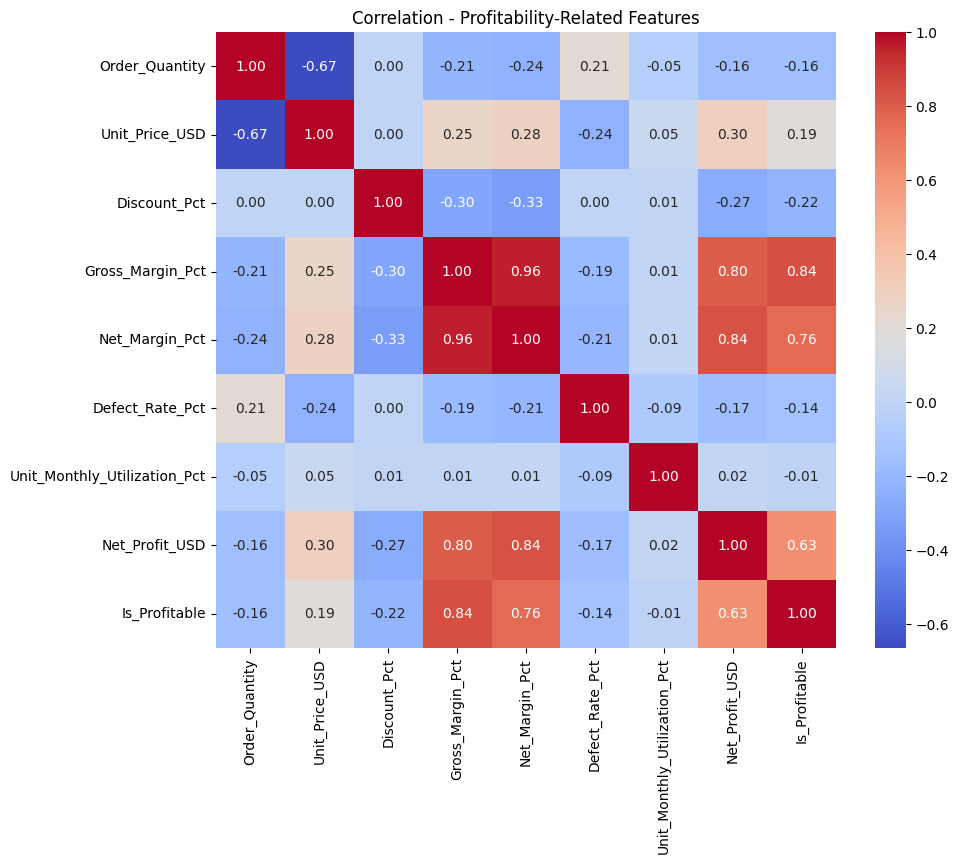

In [228]:
cols_of_interest = ['Order_Quantity', 'Unit_Price_USD', 'Discount_Pct',
                     'Gross_Margin_Pct', 'Net_Margin_Pct', 'Defect_Rate_Pct',
                     'Unit_Monthly_Utilization_Pct', 'Net_Profit_USD', 'Is_Profitable']

plt.figure(figsize=(10,8))
sns.heatmap(df[cols_of_interest].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation - Profitability-Related Features')
plt.show()

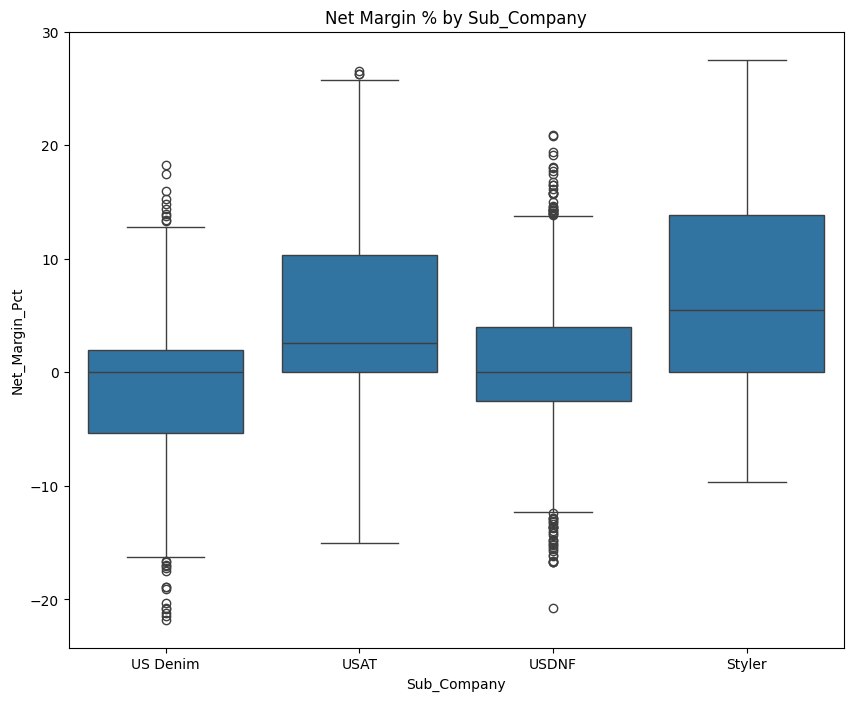

In [229]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x = 'Sub_Company', y = 'Net_Margin_Pct')
plt.title('Net Margin % by Sub_Company')
plt.show()

# **Handling the cancelled orders**
The cancelled orders, will be dispatched for some local market etc because moeny already spent on it


In [230]:
# dispatched_only = df[df['Order_Status'] == 'Dispatched']
# # Use the average cost ratio we already see in real dispatched orders,
# # to ESTIMATE what a cancelled/pending order would have cost if it had gone into production
# avg_cost_ratio = dispatched_only['Total_Cost_USD'].sum() / dispatched_only['Gross_Order_Value_USD'].sum()

# df['Estimated_Sunk_Cost_USD'] = np.where(
#     df['Order_Status'].isin(['Cancelled', 'Pending']),
#     df['Order_Quantity'] * df['Unit_Price_USD'] * avg_cost_ratio * 0.5,  # assume ~50% into production on average
#     0
# )

# df['Estimated_Impact_USD'] = np.where(
#     df['Order_Status'] == 'Cancelled',
#     -df['Estimated_Sunk_Cost_USD'],   # cancelled = real loss (negative)
#     np.where(df['Order_Status'] == 'Pending', 0, df['Net_Profit_USD'])  # pending = neutral, dispatched/delayed = actual profit
# )

# Just using dispatched and delayed orders for profit check

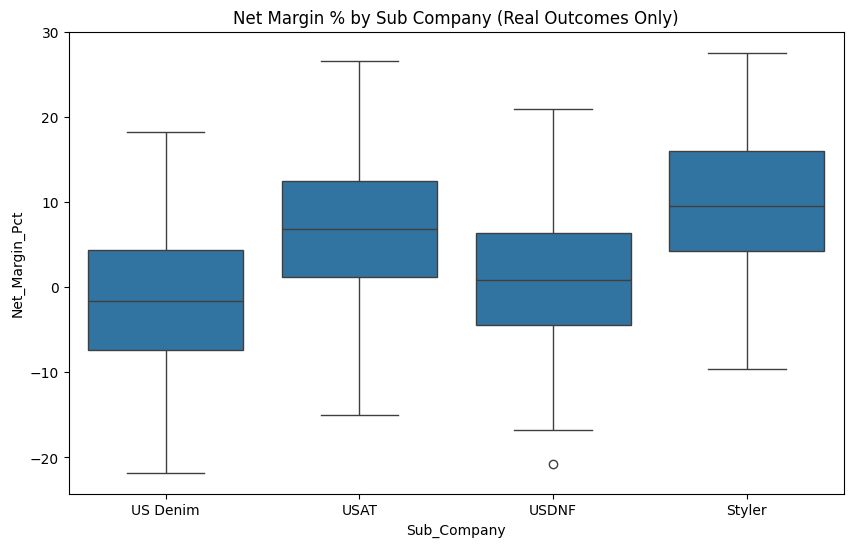

In [231]:
real_outcomes = df[df['Order_Status'].isin(['Dispatched', 'Delayed'])]

plt.figure(figsize=(10,6))
sns.boxplot(data=real_outcomes, x='Sub_Company', y='Net_Margin_Pct')
plt.title('Net Margin % by Sub Company (Real Outcomes Only)')
plt.show()

The EDA is wrapped up here
1,914 rows, 52 columns, no critical structural issues
  1. Dates are stored as text (need conversion)
  2. Division has expected NaNs (only USAT has divisions)
  3. Class balance checked for all 3 targets (Task B is notably imbalanced — 89/11)
  4. Correlation heatmap → found data leakage risk (margin/profit columns) for Task A
  5. Boxplot → confirmed margins are broadly similar across sub-companies, once filtered to real outcomes

# Data Preprocessing





Coverting datae to date type rather than object

In [232]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Dispatch_Date'] = pd.to_datetime(df['Dispatch_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Order_ID                      4845 non-null   object        
 1   Order_Date                    4845 non-null   datetime64[ns]
 2   Dispatch_Date                 4845 non-null   datetime64[ns]
 3   Fiscal_Year                   4845 non-null   object        
 4   Fiscal_Quarter                4845 non-null   object        
 5   Year                          4845 non-null   int64         
 6   Month                         4845 non-null   int64         
 7   Sub_Company                   4845 non-null   object        
 8   Division                      2440 non-null   object        
 9   Unit                          4845 non-null   object        
 10  Unit_Employee_Count           4845 non-null   int64         
 11  Unit_Monthly_Utilization_Pct  

# Handle thee null values in the division, because only USAT has divisions.

In [233]:
df['Division'] = df['Division'].fillna('Not Applicable')
df['Division'].value_counts()

,count
Division,
Not Applicable,2405
UK,1458
USA,982


In [234]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Dispatch_Date',
 'Fiscal_Year',
 'Fiscal_Quarter',
 'Year',
 'Month',
 'Sub_Company',
 'Division',
 'Unit',
 'Unit_Employee_Count',
 'Unit_Monthly_Utilization_Pct',
 'Customer_Name',
 'Customer_Country',
 'Customer_Segment',
 'Order_Priority',
 'Product_Category',
 'UOM',
 'Order_Quantity',
 'Unit_Price_USD',
 'Gross_Order_Value_USD',
 'Discount_Pct',
 'Discount_Amount_USD',
 'Net_Order_Value_USD',
 'Dispatch_Quantity',
 'Dispatch_Value_USD',
 'Exchange_Rate_PKR_per_USD',
 'Dispatch_Value_PKR',
 'Raw_Material_Cost_USD',
 'Labor_Cost_USD',
 'Overhead_Cost_USD',
 'Energy_Cost_USD',
 'COGS_USD',
 'Freight_Cost_USD',
 'Insurance_Cost_USD',
 'Duty_Tax_USD',
 'Total_Cost_USD',
 'Gross_Profit_USD',
 'Net_Profit_USD',
 'Gross_Margin_Pct',
 'Net_Margin_Pct',
 'Payment_Terms',
 'Advance_Payment_Pct',
 'Credit_Days',
 'Payment_Delay_Days',
 'Defect_Rate_Pct',
 'Return_Quantity',
 'Shipping_Mode',
 'Order_Status',
 'Is_Profitable',
 'Is_Delayed_Payment',
 'Is_High_Val

# Using the required columns for profit check , rather than dropping the columns

In [235]:
task_a_features = [
    'Sub_Company', 'Division', 'Unit', 'Unit_Employee_Count',
    'Unit_Monthly_Utilization_Pct', 'Customer_Country', 'Customer_Segment',
    'Order_Priority', 'Product_Category', 'UOM', 'Order_Quantity',
    'Unit_Price_USD', 'Discount_Pct', 'Exchange_Rate_PKR_per_USD',
    'Payment_Terms', 'Advance_Payment_Pct', 'Credit_Days',
    'Defect_Rate_Pct', 'Shipping_Mode', 'Year', 'Month', 'Fiscal_Quarter'
]
target_a = 'Is_Profitable'
X_task_a = df[task_a_features]
y_task_a = df['Is_Profitable']

X_task_a.head()

,Sub_Company,Division,Unit,Unit_Employee_Count,Unit_Monthly_Utilization_Pct,Customer_Country,Customer_Segment,Order_Priority,Product_Category,UOM,Order_Quantity,Unit_Price_USD,Discount_Pct,Exchange_Rate_PKR_per_USD,Payment_Terms,Advance_Payment_Pct,Credit_Days,Defect_Rate_Pct,Shipping_Mode,Year,Month,Fiscal_Quarter
0,US Denim,Not Applicable,Unit 6,900,65.30,Bangladesh,Regular,Medium,Denim Fabric,Meters,20690,3.90,1.34,277.12,TT 30 Days,1.6,30,1.80,Sea,2025,1,Q3
1,US Denim,Not Applicable,Unit 6,900,65.30,Bangladesh,Key Account,Medium,Denim Fabric,Meters,55603,5.08,2.74,277.12,LC 90 Days,0.0,90,1.82,Sea,2025,1,Q3
2,US Denim,Not Applicable,Unit 7,950,67.32,Germany,Regular,Medium,Denim Fabric,Meters,35378,5.78,0.13,277.12,LC 90 Days,0.0,90,1.42,Sea,2025,1,Q3
3,USAT,UK,Unit 3,1600,70.69,UK,New Customer,Medium,Twill Garments,Pieces,11000,7.86,0.40,277.12,LC 90 Days,0.0,90,2.69,Sea,2025,1,Q3
4,USAT,USA,Unit 5,1100,74.02,USA,Key Account,Low,Denim Garments,Pieces,3696,25.64,3.09,277.12,LC 60 Days,0.0,60,1.20,Sea,2025,1,Q3


# MOving to one hot encoding on divisions column

In [236]:
X_task_a_encoded = pd.get_dummies(X_task_a, columns=[
    'Sub_Company', 'Division', 'Unit', 'Customer_Country',
    'Customer_Segment', 'Order_Priority', 'Product_Category',
    'UOM', 'Payment_Terms', 'Shipping_Mode', 'Fiscal_Quarter'
], drop_first=True)

X_task_a_encoded.shape

(4845, 54)

In [237]:
X_task_a_encoded.columns.tolist()

['Unit_Employee_Count',
 'Unit_Monthly_Utilization_Pct',
 'Order_Quantity',
 'Unit_Price_USD',
 'Discount_Pct',
 'Exchange_Rate_PKR_per_USD',
 'Advance_Payment_Pct',
 'Credit_Days',
 'Defect_Rate_Pct',
 'Year',
 'Month',
 'Sub_Company_US Denim',
 'Sub_Company_USAT',
 'Sub_Company_USDNF',
 'Division_UK',
 'Division_USA',
 'Unit_Unit 10',
 'Unit_Unit 2',
 'Unit_Unit 3',
 'Unit_Unit 4',
 'Unit_Unit 5',
 'Unit_Unit 6',
 'Unit_Unit 7',
 'Unit_Unit 8',
 'Unit_Unit 9',
 'Customer_Country_Germany',
 'Customer_Country_Italy',
 'Customer_Country_Netherlands',
 'Customer_Country_Saudi Arabia',
 'Customer_Country_Sri Lanka',
 'Customer_Country_Turkey',
 'Customer_Country_UAE',
 'Customer_Country_UK',
 'Customer_Country_USA',
 'Customer_Segment_New Customer',
 'Customer_Segment_Regular',
 'Order_Priority_Low',
 'Order_Priority_Medium',
 'Product_Category_Denim Garments',
 'Product_Category_Footwear',
 'Product_Category_Lifestyle Apparel',
 'Product_Category_Non-Denim Fabric',
 'Product_Category_Twi

# Train/Test split data

In [238]:
y_task_a.head(10)

,Is_Profitable
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,1


In [239]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_task_a_encoded, y_task_a, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3876, 54) (969, 54) (3876,) (969,)


# Feature scaling bcz of huge differences just like order quatity and discount percentage

In [240]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [241]:
X_train_scaled[:5]

array([[-0.29991266,  0.38874987, -0.25004338, -0.77627282,  0.46885731,
        -0.65507887, -0.19112354, -0.06519922,  0.59569318, -0.65111671,
        -0.03274442,  2.06723714, -1.01246154, -0.50837148, -0.6547341 ,
        -0.50957679, -0.33113119, -0.34158611, -0.32679675, -0.33161067,
        -0.33638276, -0.32969024,  3.14933483, -0.33543159, -0.34111501,
        -0.30657486, -0.15851066, -0.20409671, -0.15063629, -0.17797249,
        -0.1787425 , -0.2161455 , -0.7812191 , -0.6298863 ,  2.27636073,
        -0.99742334, -0.56582991, -1.0229675 , -0.57337808, -0.22577896,
        -0.23016241, -0.50837148, -0.59085737, -0.22577896, -1.12017825,
        -0.44263663, -0.43846156,  2.25282825, -0.44596691, -0.46208804,
         0.57099465, -0.51038006, -0.59165213,  1.42912077],
       [-1.04622845, -0.84947899,  2.16449685, -1.03227657,  0.80264203,
        -1.45922884, -0.57939248,  1.534245  , -0.20699458, -0.65111671,
        -0.94581891, -0.48373744, -1.01246154,  1.96706551, -0.

# **Now moving to the model training**

# Decision Tree

In [242]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.5779153766769866
              precision    recall  f1-score   support

           0       0.57      0.62      0.59       482
           1       0.59      0.54      0.56       487

    accuracy                           0.58       969
   macro avg       0.58      0.58      0.58       969
weighted avg       0.58      0.58      0.58       969



# Checking model overfitting because of bad results

In [243]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print("Dummy baseline accuracy:", dummy.score(X_test, y_test))

Dummy baseline accuracy: 0.49742002063983487


In [244]:
print("Train accuracy:", dt_model.score(X_train, y_train))
print("Test accuracy:", dt_model.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.5779153766769866


# Lets prune because overfitting occuring

In [245]:
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)

print("Train accuracy:", dt_model.score(X_train, y_train))
print("Test accuracy:", dt_model.score(X_test, y_test))

Train accuracy: 0.6658926728586171
Test accuracy: 0.6274509803921569


# Naive Bayes Classifier

In [246]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Train accuracy:", nb_model.score(X_train, y_train))
print("Test accuracy:", nb_model.score(X_test, y_test))

y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))

Train accuracy: 0.6150670794633643
Test accuracy: 0.6388028895768834
              precision    recall  f1-score   support

           0       0.65      0.58      0.62       482
           1       0.63      0.69      0.66       487

    accuracy                           0.64       969
   macro avg       0.64      0.64      0.64       969
weighted avg       0.64      0.64      0.64       969



# KNN

In [247]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("Train accuracy:", knn_model.score(X_train_scaled, y_train))
print("Test accuracy:", knn_model.score(X_test_scaled, y_test))

y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

Train accuracy: 0.7260061919504643
Test accuracy: 0.5727554179566563
              precision    recall  f1-score   support

           0       0.56      0.62      0.59       482
           1       0.58      0.53      0.55       487

    accuracy                           0.57       969
   macro avg       0.57      0.57      0.57       969
weighted avg       0.57      0.57      0.57       969



# SVM

In [248]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

print("Train accuracy:", svm_model.score(X_train_scaled, y_train))
print("Test accuracy:", svm_model.score(X_test_scaled, y_test))

y_pred_svm = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

Train accuracy: 0.6991744066047472
Test accuracy: 0.6398348813209495
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       482
           1       0.65      0.61      0.63       487

    accuracy                           0.64       969
   macro avg       0.64      0.64      0.64       969
weighted avg       0.64      0.64      0.64       969



# ANN

In [249]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)

print("Train accuracy:", ann_model.score(X_train_scaled, y_train))
print("Test accuracy:", ann_model.score(X_test_scaled, y_test))

y_pred_ann = ann_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_ann))

Train accuracy: 0.9184726522187823
Test accuracy: 0.5799793601651186
              precision    recall  f1-score   support

           0       0.57      0.63      0.60       482
           1       0.59      0.53      0.56       487

    accuracy                           0.58       969
   macro avg       0.58      0.58      0.58       969
weighted avg       0.58      0.58      0.58       969



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Displaing the results of all the models

In [250]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_predictions = {
    'Decision Tree': (dt_model, X_test, X_train),
    'Naive Bayes': (nb_model, X_test, X_train),
    'KNN': (knn_model, X_test_scaled, X_train_scaled),
    'SVM': (svm_model, X_test_scaled, X_train_scaled),
    'ANN': (ann_model, X_test_scaled, X_train_scaled),
}

results = []
for name, (model, X_te, X_tr) in model_predictions.items():
    y_pred = model.predict(X_te)
    results.append({
        'Model': name,
        'Train_Accuracy': round(model.score(X_tr, y_train), 4),
        'Test_Accuracy': round(model.score(X_te, y_test), 4),
        'Precision_Class0': round(precision_score(y_test, y_pred, pos_label=0), 4),
        'Recall_Class0': round(recall_score(y_test, y_pred, pos_label=0), 4),
        'F1_Class0': round(f1_score(y_test, y_pred, pos_label=0), 4),
    })
results.append({
    'Model': 'Dummy Baseline',
    'Train_Accuracy': round(dummy.score(X_train, y_train), 4),
    'Test_Accuracy': round(dummy.score(X_test, y_test), 4),
    'Precision_Class0': 0.0,
    'Recall_Class0': 0.0,
    'F1_Class0': 0.0,
})

results_df = pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Train_Accuracy,Test_Accuracy,Precision_Class0,Recall_Class0,F1_Class0
0,SVM,0.6992,0.6398,0.6301,0.6680,0.6485
1,Naive Bayes,0.6151,0.6388,0.6535,0.5830,0.6162
2,Decision Tree,0.6659,0.6275,0.6397,0.5747,0.6055
3,ANN,0.9185,0.5800,0.5704,0.6307,0.5990
4,KNN,0.7260,0.5728,0.5646,0.6162,0.5893
5,Dummy Baseline,0.5139,0.4974,0.0000,0.0000,0.0000


# Visual Bar Chart

/tmp/ipykernel_1952/2980629415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Test_Accuracy', palette=colors)


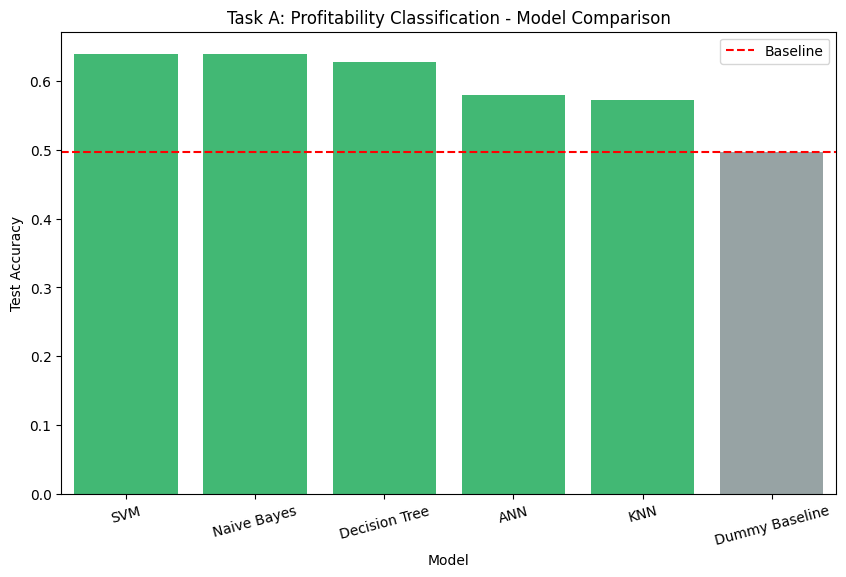

In [251]:
plt.figure(figsize=(10,6))
colors = ['#2ecc71' if m != 'Dummy Baseline' else '#95a5a6' for m in results_df['Model']]
sns.barplot(data=results_df, x='Model', y='Test_Accuracy', palette=colors)
plt.axhline(y=results_df[results_df['Model']=='Dummy Baseline']['Test_Accuracy'].values[0],
            color='red', linestyle='--', label='Baseline')
plt.title('Task A: Profitability Classification - Model Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15)
plt.legend()
plt.show()

# **Now we are moving to task B. Payment delay prediction**

In [252]:
df_taskb = df[df['Order_Status'].isin(['Dispatched', 'Delayed'])].copy()
print(df_taskb.shape)
print(df_taskb['Is_Delayed_Payment'].value_counts())

(3521, 52)
Is_Delayed_Payment
0    2697
1     824
Name: count, dtype: int64


# Features list

In [253]:
task_b_features = [
    'Sub_Company', 'Division', 'Unit', 'Customer_Country', 'Customer_Segment',
    'Order_Priority', 'Product_Category', 'UOM', 'Order_Quantity', 'Unit_Price_USD',
    'Gross_Order_Value_USD', 'Discount_Pct', 'Payment_Terms', 'Advance_Payment_Pct',
    'Credit_Days', 'Shipping_Mode', 'Year', 'Month', 'Fiscal_Quarter'
]

X_task_b = df_taskb[task_b_features].copy()
X_task_b['Division'] = X_task_b['Division'].fillna('Not Applicable')
y_task_b = df_taskb['Is_Delayed_Payment']

X_task_b.shape

(3521, 19)

# One hot encoding on categorical data

In [254]:
cat_cols_b = X_task_b.select_dtypes(include=['object', 'string']).columns.tolist()
print(cat_cols_b)

X_task_b_encoded = pd.get_dummies(X_task_b, columns=cat_cols_b, drop_first=True)
X_task_b_encoded.shape

['Sub_Company', 'Division', 'Unit', 'Customer_Country', 'Customer_Segment', 'Order_Priority', 'Product_Category', 'UOM', 'Payment_Terms', 'Shipping_Mode', 'Fiscal_Quarter']


(3521, 51)

# Spliting data

In [255]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_task_b_encoded, y_task_b, test_size=0.2, random_state=42, stratify=y_task_b
)

print(X_train_b.shape, X_test_b.shape)
print(y_train_b.value_counts(normalize=True))
print(y_test_b.value_counts(normalize=True))

(2816, 51) (705, 51)
Is_Delayed_Payment
0    0.76598
1    0.23402
Name: proportion, dtype: float64
Is_Delayed_Payment
0    0.765957
1    0.234043
Name: proportion, dtype: float64


# Scaling data

In [256]:
from sklearn.preprocessing import StandardScaler

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# Dummy Classifier

In [257]:
from sklearn.dummy import DummyClassifier

dummy_b = DummyClassifier(strategy='most_frequent')
dummy_b.fit(X_train_b, y_train_b)
print("Dummy baseline accuracy:", dummy_b.score(X_test_b, y_test_b))

Dummy baseline accuracy: 0.7659574468085106


# Decision Tree

In [258]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model_b = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_model_b.fit(X_train_b, y_train_b)

print("Train accuracy:", dt_model_b.score(X_train_b, y_train_b))
print("Test accuracy:", dt_model_b.score(X_test_b, y_test_b))

y_pred_dt_b = dt_model_b.predict(X_test_b)
print(classification_report(y_test_b, y_pred_dt_b))

Train accuracy: 0.7745028409090909
Test accuracy: 0.750354609929078
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       540
           1       0.24      0.03      0.05       165

    accuracy                           0.75       705
   macro avg       0.50      0.50      0.45       705
weighted avg       0.64      0.75      0.67       705



# Naive Bayes

In [259]:
from sklearn.naive_bayes import GaussianNB

nb_model_b = GaussianNB()
nb_model_b.fit(X_train_b, y_train_b)

print("Train accuracy:", nb_model_b.score(X_train_b, y_train_b))
print("Test accuracy:", nb_model_b.score(X_test_b, y_test_b))

y_pred_nb_b = nb_model_b.predict(X_test_b)
print(classification_report(y_test_b, y_pred_nb_b))

Train accuracy: 0.5571732954545454
Test accuracy: 0.5390070921985816
              precision    recall  f1-score   support

           0       0.85      0.49      0.62       540
           1       0.30      0.71      0.42       165

    accuracy                           0.54       705
   macro avg       0.57      0.60      0.52       705
weighted avg       0.72      0.54      0.57       705



# KNN

In [260]:
from sklearn.neighbors import KNeighborsClassifier

knn_model_b = KNeighborsClassifier(n_neighbors=5)
knn_model_b.fit(X_train_b_scaled, y_train_b)

print("Train accuracy:", knn_model_b.score(X_train_b_scaled, y_train_b))
print("Test accuracy:", knn_model_b.score(X_test_b_scaled, y_test_b))

y_pred_knn_b = knn_model_b.predict(X_test_b_scaled)
print(classification_report(y_test_b, y_pred_knn_b))

Train accuracy: 0.8103693181818182
Test accuracy: 0.7191489361702128
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       540
           1       0.31      0.17      0.22       165

    accuracy                           0.72       705
   macro avg       0.55      0.53      0.52       705
weighted avg       0.67      0.72      0.69       705



# SVM

In [261]:
from sklearn.svm import SVC

svm_model_b = SVC(random_state=42, probability=True, class_weight='balanced')
svm_model_b.fit(X_train_b_scaled, y_train_b)

print("Train accuracy:", svm_model_b.score(X_train_b_scaled, y_train_b))
print("Test accuracy:", svm_model_b.score(X_test_b_scaled, y_test_b))

y_pred_svm_b = svm_model_b.predict(X_test_b_scaled)
print(classification_report(y_test_b, y_pred_svm_b))

Train accuracy: 0.6750710227272727
Test accuracy: 0.577304964539007
              precision    recall  f1-score   support

           0       0.84      0.55      0.67       540
           1       0.31      0.67      0.42       165

    accuracy                           0.58       705
   macro avg       0.58      0.61      0.55       705
weighted avg       0.72      0.58      0.61       705



# ANN

In [262]:
from sklearn.neural_network import MLPClassifier

ann_model_b = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42)
ann_model_b.fit(X_train_b_scaled, y_train_b)

print("Train accuracy:", ann_model_b.score(X_train_b_scaled, y_train_b))
print("Test accuracy:", ann_model_b.score(X_test_b_scaled, y_test_b))

y_pred_ann_b = ann_model_b.predict(X_test_b_scaled)
print(classification_report(y_test_b, y_pred_ann_b))

Train accuracy: 0.9854403409090909
Test accuracy: 0.675177304964539
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       540
           1       0.29      0.28      0.29       165

    accuracy                           0.68       705
   macro avg       0.54      0.54      0.54       705
weighted avg       0.67      0.68      0.67       705



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Results Visualization

In [263]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_predictions_b = {
    'Decision Tree': (dt_model_b, X_test_b, X_train_b),
    'Naive Bayes': (nb_model_b, X_test_b, X_train_b),
    'KNN': (knn_model_b, X_test_b_scaled, X_train_b_scaled),
    'SVM (balanced)': (svm_model_b, X_test_b_scaled, X_train_b_scaled),
    'ANN': (ann_model_b, X_test_b_scaled, X_train_b_scaled),
}

results_b = []
for name, (model, X_te, X_tr) in model_predictions_b.items():
    y_pred = model.predict(X_te)
    results_b.append({
        'Model': name,
        'Train_Accuracy': round(model.score(X_tr, y_train_b), 4),
        'Test_Accuracy': round(model.score(X_te, y_test_b), 4),
        'Precision_Class1': round(precision_score(y_test_b, y_pred, pos_label=1), 4),
        'Recall_Class1': round(recall_score(y_test_b, y_pred, pos_label=1), 4),
        'F1_Class1': round(f1_score(y_test_b, y_pred, pos_label=1), 4),
    })

results_b.append({
    'Model': 'Dummy Baseline',
    'Train_Accuracy': round(dummy_b.score(X_train_b, y_train_b), 4),
    'Test_Accuracy': round(dummy_b.score(X_test_b, y_test_b), 4),
    'Precision_Class1': 0.0,
    'Recall_Class1': 0.0,
    'F1_Class1': 0.0,
})

results_b_df = pd.DataFrame(results_b).sort_values('Recall_Class1', ascending=False).reset_index(drop=True)
results_b_df

,Model,Train_Accuracy,Test_Accuracy,Precision_Class1,Recall_Class1,F1_Class1
0,Naive Bayes,0.5572,0.5390,0.2970,0.7091,0.4186
1,SVM (balanced),0.6751,0.5773,0.3116,0.6667,0.4247
2,ANN,0.9854,0.6752,0.2949,0.2788,0.2866
3,KNN,0.8104,0.7191,0.3146,0.1697,0.2205
4,Decision Tree,0.7745,0.7504,0.2381,0.0303,0.0538
5,Dummy Baseline,0.7660,0.7660,0.0000,0.0000,0.0000


/tmp/ipykernel_1952/1453803437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_b_df, x='Model', y='Recall_Class1', palette=colors_b)


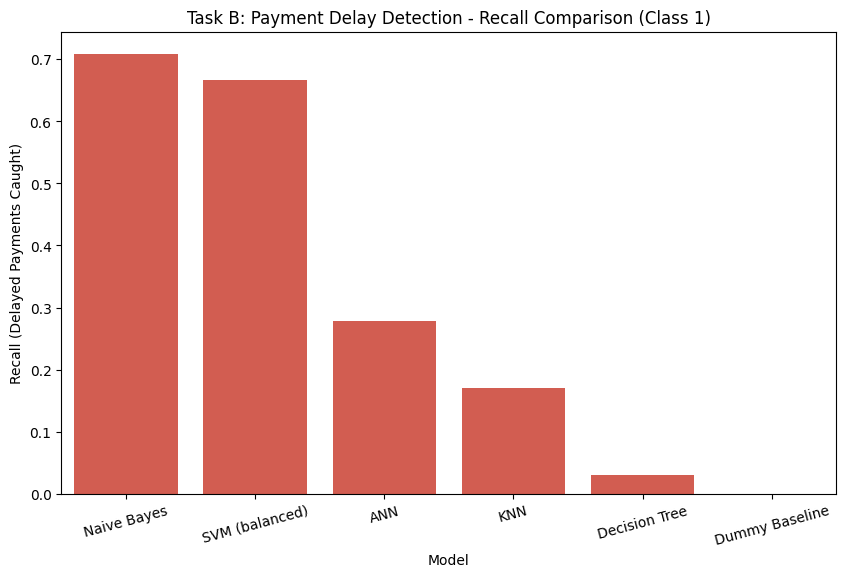

In [264]:
plt.figure(figsize=(10,6))
colors_b = ['#e74c3c' if m != 'Dummy Baseline' else '#95a5a6' for m in results_b_df['Model']]
sns.barplot(data=results_b_df, x='Model', y='Recall_Class1', palette=colors_b)
plt.title('Task B: Payment Delay Detection - Recall Comparison (Class 1)')
plt.ylabel('Recall (Delayed Payments Caught)')
plt.xticks(rotation=15)
plt.show()

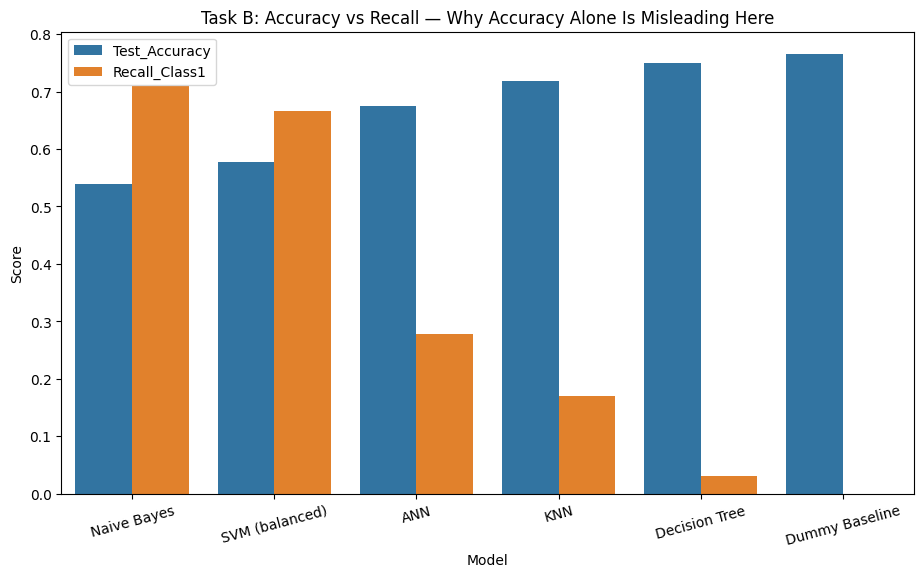

In [265]:
plot_df = results_b_df.melt(id_vars='Model', value_vars=['Test_Accuracy', 'Recall_Class1'],
                              var_name='Metric', value_name='Score')

plt.figure(figsize=(11,6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Task B: Accuracy vs Recall — Why Accuracy Alone Is Misleading Here')
plt.xticks(rotation=15)
plt.legend(title='')
plt.show()

# Task C - Next month profit prediction

In [266]:
monthly = df.groupby(['Year', 'Month']).agg({
    'Net_Profit_USD': 'sum',
    'Order_ID': 'count',
    'Dispatch_Value_USD': 'sum'
}).reset_index()

monthly.columns = ['Year', 'Month', 'Total_Profit_USD', 'Order_Count', 'Total_Revenue_USD']
monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly

,Year,Month,Total_Profit_USD,Order_Count,Total_Revenue_USD
0,2025,1,691861.56,199,12717114.16
1,2025,2,610065.30,204,13067943.79
2,2025,3,731162.02,244,16433658.25
3,2025,4,762402.40,252,16904265.38
4,2025,5,595558.41,249,16729938.89
5,2025,6,730968.00,279,18596571.46
6,2025,7,771604.28,314,20088062.27
7,2025,8,1008678.82,339,21830071.27
8,2025,9,1160787.43,348,25378710.02
9,2025,10,882416.47,368,23739376.89


In [268]:
monthly['Previous_Month_Profit'] = monthly['Total_Profit_USD'].shift(1)
monthly['Rolling_3Month_Avg'] = monthly['Total_Profit_USD'].rolling(window=3).mean()
monthly['Month_Num'] = monthly['Month']

monthly_clean = monthly.dropna().reset_index(drop=True)
monthly_clean

,Year,Month,Total_Profit_USD,Order_Count,Total_Revenue_USD,Previous_Month_Profit,Rolling_3Month_Avg,Month_Num
0,2025,3,731162.02,244,16433658.25,610065.30,6.776963e+05,3
1,2025,4,762402.40,252,16904265.38,731162.02,7.012099e+05,4
2,2025,5,595558.41,249,16729938.89,762402.40,6.963743e+05,5
3,2025,6,730968.00,279,18596571.46,595558.41,6.963096e+05,6
4,2025,7,771604.28,314,20088062.27,730968.00,6.993769e+05,7
5,2025,8,1008678.82,339,21830071.27,771604.28,8.370837e+05,8
6,2025,9,1160787.43,348,25378710.02,1008678.82,9.803568e+05,9
7,2025,10,882416.47,368,23739376.89,1160787.43,1.017294e+06,10
8,2025,11,908326.90,340,19432631.02,882416.47,9.838436e+05,11
9,2025,12,466736.92,268,16641997.84,908326.90,7.524934e+05,12


# Spliting

In [269]:
feature_cols = ['Year', 'Month', 'Previous_Month_Profit', 'Rolling_3Month_Avg']
X_d = monthly_clean[feature_cols]
y_d = monthly_clean['Total_Profit_USD']

print(X_d.shape, y_d.shape)

(16, 4) (16,)


In [270]:
split_point = 12

X_train_d = X_d.iloc[:split_point]
X_test_d = X_d.iloc[split_point:]
y_train_d = y_d.iloc[:split_point]
y_test_d = y_d.iloc[split_point:]

print("Train:", X_train_d.shape, " Test:", X_test_d.shape)

Train: (12, 4)  Test: (4, 4)


# Linear Regression

In [271]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_d, y_train_d)

y_pred_lr = lr_model.predict(X_test_d)

print("Actual values:   ", y_test_d.values)
print("Predicted values:", y_pred_lr.round(2))
print()
print("MAE:", round(mean_absolute_error(y_test_d, y_pred_lr), 2))
print("RMSE:", round(mean_squared_error(y_test_d, y_pred_lr) ** 0.5, 2))
print("R²:", round(r2_score(y_test_d, y_pred_lr), 4))

Actual values:    [590408.3  867929.95 778772.6  796972.34]
Predicted values: [423110.6  580182.13 586667.83 710604.24]

MAE: 183379.6
RMSE: 196946.07
R²: -2.6835


# SVM, Decision tree ,KNN, ANN regressors

In [272]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

dt_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reg.fit(X_train_d, y_train_d)
y_pred_dt_reg = dt_reg.predict(X_test_d)
print("Decision Tree R²:", round(r2_score(y_test_d, y_pred_dt_reg), 4))

svr_reg = SVR()
svr_reg.fit(X_train_d_scaled, y_train_d)
y_pred_svr = svr_reg.predict(X_test_d_scaled)
print("SVR R²:", round(r2_score(y_test_d, y_pred_svr), 4))

knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train_d_scaled, y_train_d)
y_pred_knn_reg = knn_reg.predict(X_test_d_scaled)
print("KNN R²:", round(r2_score(y_test_d, y_pred_knn_reg), 4))

ann_reg = MLPRegressor(hidden_layer_sizes=(16,8), max_iter=1000, random_state=42)
ann_reg.fit(X_train_d_scaled, y_train_d)
y_pred_ann_reg = ann_reg.predict(X_test_d_scaled)
print("ANN R²:", round(r2_score(y_test_d, y_pred_ann_reg), 4))

Decision Tree R²: -4.2886
SVR R²: -0.0131
KNN R²: -2.512
ANN R²: -54.4731


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# Predicting top 5 customers

In [273]:
usat_usa = df[(df['Sub_Company'] == 'USAT') & (df['Division'] == 'USA')].copy()
print(usat_usa.shape)
print(usat_usa[['Year', 'Month']].drop_duplicates().sort_values(['Year','Month']))

(982, 52)
      Year  Month
4     2025      1
206   2025      2
406   2025      3
650   2025      4
903   2025      5
1152  2025      6
1430  2025      7
1745  2025      8
2090  2025      9
2437  2025     10
2801  2025     11
3138  2025     12
3415  2026      1
3611  2026      2
3813  2026      3
4048  2026      4
4299  2026      5
4569  2026      6


In [274]:
latest_year = df['Year'].max()
latest_month = df[df['Year'] == latest_year]['Month'].max()
print(f"Latest month in dataset: {latest_month}/{latest_year}")

Latest month in dataset: 6/2026


In [275]:
last_month_data = usat_usa[(usat_usa['Year'] == latest_year) & (usat_usa['Month'] == latest_month)]

top5_last_month = last_month_data.groupby('Customer_Name').agg(
    Total_Profit_USD=('Net_Profit_USD', 'sum'),
    Order_Count=('Order_ID', 'count')
).sort_values('Total_Profit_USD', ascending=False).head(5)

print(f"Top 5 US Apparel Customers - {latest_month}/{latest_year}")
top5_last_month

Top 5 US Apparel Customers - 6/2026


,Total_Profit_USD,Order_Count
Customer_Name,,
Bowman-Haney,43713.23,1
"Calderon, Murray and Bennett",29976.13,1
"Perez, Campbell and Foster",23012.69,1
"Rodriguez, Morales and Miller",22664.99,1
Parks Inc,18747.26,1


In [276]:
year_data = usat_usa[usat_usa['Year'] == latest_year]

top5_year = year_data.groupby('Customer_Name').agg(
    Total_Profit_USD=('Net_Profit_USD', 'sum'),
    Order_Count=('Order_ID', 'count')
).sort_values('Total_Profit_USD', ascending=False).head(5)

print(f"Top 5 US Apparel Customers - Full Year {latest_year}")
top5_year

Top 5 US Apparel Customers - Full Year 2026


,Total_Profit_USD,Order_Count
Customer_Name,,
Bowman-Haney,43713.23,1
Carter-George,38350.69,1
"Nichols, Stanley and Trevino",34983.43,1
"Kent, Schaefer and Lowery",32035.30,1
Turner Inc,30187.26,1


# Serve a single prediction (added for the FastAPI integration)

Reads a new order from `INPUT_JSON_PATH`, predicts profitability (SVM) and payment delay (Naive Bayes) using the models already trained above, and writes both results to `OUTPUT_JSON_PATH`.

In [ ]:
import json as _json

with open(INPUT_JSON_PATH, encoding="utf-8") as _f:
    _order = _json.load(_f)

_now_year = pd.Timestamp.now().year
_now_month = pd.Timestamp.now().month


def _fiscal_quarter(month):
    if month in (7, 8, 9):
        return "Q1"
    if month in (10, 11, 12):
        return "Q2"
    if month in (1, 2, 3):
        return "Q3"
    return "Q4"


# Real per-unit and per-payment-term stats computed from the training dataset,
# used to backfill features the simplified order form doesn't collect.
_unit_stats = df.groupby("Unit").agg(
    Unit_Employee_Count=("Unit_Employee_Count", "first"),
    Unit_Monthly_Utilization_Pct=("Unit_Monthly_Utilization_Pct", "mean"),
    Defect_Rate_Pct=("Defect_Rate_Pct", "mean"),
)
_payment_stats = df.groupby("Payment_Terms").agg(
    Advance_Payment_Pct=("Advance_Payment_Pct", "mean"),
    Credit_Days=("Credit_Days", "mean"),
)
_exchange_rate = df["Exchange_Rate_PKR_per_USD"].iloc[-1]


def _build_row(order):
    unit_row = _unit_stats.loc[order["Unit"]]
    payment_row = _payment_stats.loc[order["Payment_Terms"]]
    return {
        "Sub_Company": order["Sub_Company"],
        "Division": order.get("Division") or "Not Applicable",
        "Unit": order["Unit"],
        "Customer_Country": order["Customer_Country"],
        "Customer_Segment": order["Customer_Segment"],
        "Order_Priority": order["Order_Priority"],
        "Product_Category": order["Product_Category"],
        "UOM": order["UOM"],
        "Order_Quantity": order["Order_Quantity"],
        "Unit_Price_USD": order["Unit_Price_USD"],
        "Discount_Pct": order["Discount_Pct"],
        "Payment_Terms": order["Payment_Terms"],
        "Shipping_Mode": order["Shipping_Mode"],
        "Year": _now_year,
        "Month": _now_month,
        "Fiscal_Quarter": _fiscal_quarter(_now_month),
        "Unit_Employee_Count": unit_row["Unit_Employee_Count"],
        "Unit_Monthly_Utilization_Pct": unit_row["Unit_Monthly_Utilization_Pct"],
        "Defect_Rate_Pct": unit_row["Defect_Rate_Pct"],
        "Exchange_Rate_PKR_per_USD": _exchange_rate,
        "Advance_Payment_Pct": payment_row["Advance_Payment_Pct"],
        "Credit_Days": payment_row["Credit_Days"],
        "Gross_Order_Value_USD": order["Order_Quantity"] * order["Unit_Price_USD"],
    }


_categorical_cols = [
    "Sub_Company", "Division", "Unit", "Customer_Country", "Customer_Segment",
    "Order_Priority", "Product_Category", "UOM", "Payment_Terms", "Shipping_Mode",
    "Fiscal_Quarter",
]


def _encode_row(row, column_order):
    row_df = pd.DataFrame([row])
    present = [c for c in _categorical_cols if c in row_df.columns]
    encoded = pd.get_dummies(row_df, columns=present, drop_first=False)
    return encoded.reindex(columns=column_order, fill_value=0)


def _explain(order, positive, factors_true, factors_false):
    return factors_true if positive else factors_false


_row = _build_row(_order)

# --- Profitability (SVM, scaled) ---
_features_a = _encode_row(_row, X_task_a_encoded.columns)
_features_a_scaled = scaler.transform(_features_a)
_proba_a = svm_model.predict_proba(_features_a_scaled)[0]
_prob_profitable = float(_proba_a[1])
_is_profitable = _prob_profitable >= 0.5
_confidence_a = round((_prob_profitable if _is_profitable else 1 - _prob_profitable) * 100, 1)

_factors_a = []
if _order["Discount_Pct"] >= 6:
    _factors_a.append(f"High discount of {_order['Discount_Pct']}% compresses margin")
elif _order["Discount_Pct"] <= 2:
    _factors_a.append(f"Low discount of {_order['Discount_Pct']}% protects margin")
_factors_a.append(
    "Air freight adds cost pressure vs. sea shipping" if _order["Shipping_Mode"] == "Air"
    else "Sea shipping keeps freight costs down"
)
_factors_a.append(f"Unit utilization for {_order['Unit']} averages {_row['Unit_Monthly_Utilization_Pct']:.1f}%")
if _order["Customer_Segment"] == "Key Account":
    _factors_a.append("Key Account customers tend to have stable, predictable costs")
elif _order["Customer_Segment"] == "New Customer":
    _factors_a.append("New customer relationships carry more uncertainty")

_result_profitability = {
    "prediction": "Profitable" if _is_profitable else "Not Profitable",
    "is_positive": _is_profitable,
    "confidence": _confidence_a,
    "explanation": (
        f"This order is predicted to be {'profitable' if _is_profitable else 'not profitable'} "
        f"with {_confidence_a}% confidence, based on the SVM model trained on historical order data."
    ),
    "key_factors": _factors_a[:4],
}

# --- Payment delay (Naive Bayes, unscaled) ---
_features_b = _encode_row(_row, X_task_b_encoded.columns)
_proba_b = nb_model_b.predict_proba(_features_b)[0]
_prob_delayed = float(_proba_b[1])
_is_delayed = _prob_delayed >= 0.5
_confidence_b = round((_prob_delayed if _is_delayed else 1 - _prob_delayed) * 100, 1)

_factors_b = []
_factors_b.append(f"{_order['Payment_Terms']} implies ~{_row['Credit_Days']:.0f} credit days on average")
if _row["Advance_Payment_Pct"] >= 50:
    _factors_b.append(f"{_row['Advance_Payment_Pct']:.0f}% typical advance payment lowers delay risk")
if _order["Customer_Segment"] == "New Customer":
    _factors_b.append("New customers have no on-time payment track record yet")
elif _order["Customer_Segment"] == "Key Account":
    _factors_b.append("Key Account customers have an established payment history")

_result_payment_delay = {
    "prediction": "Likely Delayed" if _is_delayed else "Likely On-Time",
    "is_positive": not _is_delayed,
    "confidence": _confidence_b,
    "explanation": (
        f"This customer is predicted to pay {'late' if _is_delayed else 'on time'} "
        f"with {_confidence_b}% confidence, based on the Naive Bayes model trained on historical order data."
    ),
    "key_factors": _factors_b[:4],
}

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as _f:
    _json.dump({"profitability": _result_profitability, "payment_delay": _result_payment_delay}, _f, indent=2)

print("Wrote", OUTPUT_JSON_PATH)
